# CorridorKey → OpenVINO: Export & Inference on Intel Hardware

This notebook demonstrates how to enable **fast inference on Intel CPUs, GPUs, and NPUs** by exporting the CorridorKey green-screen keying model to [OpenVINO](https://docs.openvino.ai/) — Intel's toolkit for optimizing and deploying deep learning models.

**Pipeline:**

1. **Install** dependencies (PyTorch, OpenVINO, etc.)
2. **Download** the CorridorKey checkpoint from HuggingFace
3. **Load** the PyTorch `GreenFormer` model
4. **Export** to OpenVINO IR via `openvino.convert_model`
5. **Run inference** on a synthetic green-screen image & video
6. **Compare** OpenVINO vs PyTorch outputs for correctness
7. **Benchmark** latency — OpenVINO on Intel hardware vs PyTorch eager

> **Note:** This notebook assumes you have cloned the [CorridorKeyOpenVINO](https://github.com/daniil-lyakhov/CorridorKeyOpenVINO) repository and are running from its root directory.
> Set `OV_DEVICE` below to `"GPU"` or `"NPU"` to target Intel integrated/discrete GPUs or NPUs.

## 1. Install Dependencies

Install the required dependencies (PyTorch, timm, OpenCV, HuggingFace Hub, OpenVINO, matplotlib).

In [1]:
import subprocess
import sys

# Install dependencies from requirements.txt (torch, timm, opencv,
# huggingface-hub, openvino, matplotlib, …)
subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-r",
        "requirements.txt",
        "--quiet",
    ]
)

# Ensure freshly-installed packages are importable in this session
import importlib  # noqa: E402
import site  # noqa: E402

importlib.invalidate_caches()
site.main()

print("✓ All dependencies installed")

✓ All dependencies installed


You should consider upgrading via the '/home/dlyakhov/Projects/CorridorKeyOpenVINO/.venv/bin/python -m pip install --upgrade pip' command.


## 2. Imports & Constants

In [2]:
from __future__ import annotations  # noqa: F404

import math
import shutil
import time
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import openvino as ov
import torch
import torch.nn.functional as F

# ── Paths ────────────────────────────────────────────────────────────────
REPO_ROOT = Path(".").resolve()
CHECKPOINT_DIR = REPO_ROOT / "checkpoints"
IR_DIR = Path("ir")  # OpenVINO IR model directory
OUTPUT_DIR = Path("output")  # inference results

# ── HuggingFace checkpoint ──────────────────────────────────────────────
HF_REPO_ID = "nikopueringer/CorridorKey_v1.0"
HF_CHECKPOINT_FILENAME = "CorridorKey_v1.0.pth"

# ── Model settings ──────────────────────────────────────────────────────
IMG_SIZE = 512  # Use 512 for a quick demo; set to 1024 or 2048 for quality
OV_DEVICE = "CPU"

# ── ImageNet normalisation stats ────────────────────────────────────────
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32).reshape(1, 1, 3)
IMAGENET_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32).reshape(1, 1, 3)

print(f"Repo root : {REPO_ROOT}")
print(f"IMG_SIZE  : {IMG_SIZE}")
print(f"OV device : {OV_DEVICE}")
print(f"OpenVINO  : {ov.__version__}")
print(f"PyTorch   : {torch.__version__}")

Repo root : /home/dlyakhov/Projects/CorridorKeyOpenVINO
IMG_SIZE  : 512
OV device : CPU
OpenVINO  : 2026.0.0-20965-c6d6a13a886-releases/2026/0
PyTorch   : 2.10.0+cu128


## 3. Download Checkpoint from HuggingFace

In [3]:
from huggingface_hub import hf_hub_download

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
ckpt_path = CHECKPOINT_DIR / HF_CHECKPOINT_FILENAME

if ckpt_path.exists():
    print(f"Checkpoint already present: {ckpt_path}")
else:
    print(f"Downloading from huggingface.co/{HF_REPO_ID} …")
    cached = hf_hub_download(repo_id=HF_REPO_ID, filename=HF_CHECKPOINT_FILENAME)
    shutil.copy2(cached, ckpt_path)
    print(f"Saved → {ckpt_path}")

print(f"Checkpoint size: {ckpt_path.stat().st_size / 1e6:.1f} MB")

Checkpoint already present: /home/dlyakhov/Projects/CorridorKeyOpenVINO/checkpoints/CorridorKey_v1.0.pth
Checkpoint size: 401.4 MB


/home/dlyakhov/Projects/CorridorKeyOpenVINO/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 4. Load the PyTorch GreenFormer Model

The model is imported from the `CorridorKey` git submodule (`CorridorKeyModule.core.model_transformer`).

**Architecture recap:**
- **Encoder:** Hiera (ViT) backbone from `timm`, patched to 4 input channels (RGB + mask)
- **Alpha decoder:** SegFormer-style head → 1-ch alpha
- **FG decoder:** Same architecture → 3-ch foreground
- **Refiner:** Dilated residual CNN that corrects coarse predictions

In [4]:
import sys

_submodule_root = str(Path("CorridorKey").resolve())
if _submodule_root not in sys.path:
    sys.path.insert(0, _submodule_root)

from CorridorKeyModule.core.model_transformer import GreenFormer  # noqa: E402


def load_torch_model(checkpoint_path: Path, img_size: int, device: str = "cpu") -> torch.nn.Module:
    """Instantiate GreenFormer, load weights, return in eval mode."""
    model = GreenFormer(
        encoder_name="hiera_base_plus_224.mae_in1k_ft_in1k",
        img_size=img_size,
        use_refiner=True,
    )
    model.to(device).eval()

    ckpt = torch.load(str(checkpoint_path), map_location=device, weights_only=True)
    state_dict = ckpt.get("state_dict", ckpt)

    # Strip _orig_mod. prefix left by torch.compile & resize pos-embeds
    model_state = model.state_dict()
    cleaned: dict[str, torch.Tensor] = {}
    for k, v in state_dict.items():
        if k.startswith("_orig_mod."):
            k = k[len("_orig_mod.") :]
        if "pos_embed" in k and k in model_state and v.shape != model_state[k].shape:
            N_src, C = v.shape[1], v.shape[2]
            N_dst = model_state[k].shape[1]
            g_src, g_dst = int(math.sqrt(N_src)), int(math.sqrt(N_dst))
            v = (
                F.interpolate(
                    v.permute(0, 2, 1).view(1, C, g_src, g_src),
                    size=(g_dst, g_dst),
                    mode="bicubic",
                    align_corners=False,
                )
                .flatten(2)
                .transpose(1, 2)
            )
        cleaned[k] = v

    missing, unexpected = model.load_state_dict(cleaned, strict=False)
    if missing:
        print(f"⚠ Missing keys: {missing}")
    if unexpected:
        print(f"⚠ Unexpected keys: {unexpected}")
    return model


torch_model = load_torch_model(ckpt_path, img_size=IMG_SIZE)
print(f"✓ PyTorch model loaded  (img_size={IMG_SIZE})")

✓ PyTorch model loaded  (img_size=512)


## 5. Export to OpenVINO IR

We use `openvino.convert_model()` which traces the PyTorch model with a dummy input and converts it directly to OpenVINO IR. No ONNX intermediate step is needed.

In [5]:
IR_DIR.mkdir(parents=True, exist_ok=True)
ir_path = IR_DIR / "corridorkey.xml"

if ir_path.exists():
    print(f"OpenVINO IR already exists: {ir_path}")
else:
    print("Converting PyTorch → OpenVINO IR …")
    dummy = torch.zeros(1, 4, IMG_SIZE, IMG_SIZE, dtype=torch.float32)
    ov_model = ov.convert_model(torch_model, example_input=dummy)
    ov.save_model(ov_model, str(ir_path))
    print(f"✓ Saved IR → {ir_path}")

# Show resulting files
for f in sorted(IR_DIR.glob("corridorkey.*")):
    print(f"  {f.name:30s}  {f.stat().st_size / 1e6:.1f} MB")

OpenVINO IR already exists: ir/corridorkey.xml
  corridorkey.bin                 144.4 MB
  corridorkey.xml                 0.9 MB


## 6. Load OpenVINO Compiled Model

Inspect the graph outputs — both should end with a `Sigmoid` node, meaning outputs are already in `[0, 1]`.

In [6]:
core = ov.Core()

# Read the model (for inspection)
ov_model = core.read_model(str(ir_path))
for i, output in enumerate(ov_model.outputs):
    node = output.get_node()
    src_node = node.input(0).get_source_output().get_node()
    print(f"Output {i}: name={output.any_name!r}, shape={output.partial_shape}, last_op={src_node.get_type_name()}")

# Compile for inference
compiled = core.compile_model(str(ir_path), OV_DEVICE)
print(f"\n✓ Compiled on {OV_DEVICE}")

Output 0: name='alpha', shape=[?,1,?,?], last_op=Sigmoid
Output 1: name='fg', shape=[?,3,?,?], last_op=Sigmoid

✓ Compiled on CPU

✓ Compiled on CPU


## 7. Preprocessing & Postprocessing Helpers

These mirror the logic in `export_and_run_openvino.py`.

In [7]:
def simple_green_mask(rgb: np.ndarray) -> np.ndarray:
    """Naive chroma-key mask: 1 = foreground, 0 = green background."""
    r, g, b = rgb[:, :, 0], rgb[:, :, 1], rgb[:, :, 2]
    green_dominance = g - np.maximum(r, b)
    mask = 1.0 - np.clip(green_dominance * 4.0, 0.0, 1.0)
    return mask[:, :, np.newaxis].astype(np.float32)


def preprocess(image_bgr: np.ndarray, img_size: int) -> tuple[np.ndarray, int, int]:
    """BGR uint8 → [1, 4, H, W] float32 (ImageNet-normalised RGB + mask)."""
    h, w = image_bgr.shape[:2]
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    mask = simple_green_mask(image_rgb)

    img_resized = cv2.resize(image_rgb, (img_size, img_size), interpolation=cv2.INTER_LINEAR)
    mask_resized = cv2.resize(mask, (img_size, img_size), interpolation=cv2.INTER_LINEAR)
    if mask_resized.ndim == 2:
        mask_resized = mask_resized[:, :, np.newaxis]

    img_norm = (img_resized - IMAGENET_MEAN) / IMAGENET_STD
    inp = np.concatenate([img_norm, mask_resized], axis=-1)
    inp = inp.transpose((2, 0, 1))[np.newaxis].astype(np.float32)
    return inp, h, w


def postprocess(alpha: np.ndarray, fg: np.ndarray, orig_h: int, orig_w: int):
    """Model output → (alpha_f32 [H,W], fg_rgb_f32 [H,W,3], comp_rgb_f32 [H,W,3])."""
    alpha_2d = np.clip(cv2.resize(alpha[0, 0], (orig_w, orig_h), interpolation=cv2.INTER_LANCZOS4), 0, 1)
    fg_hwc = np.clip(cv2.resize(fg[0].transpose(1, 2, 0), (orig_w, orig_h), interpolation=cv2.INTER_LANCZOS4), 0, 1)

    bg = np.full_like(fg_hwc, 0.35)
    alpha_3 = alpha_2d[:, :, np.newaxis]
    comp = fg_hwc * alpha_3 + bg * (1.0 - alpha_3)
    return alpha_2d, fg_hwc, comp


def make_synthetic_greenscreen(h: int = 720, w: int = 1280) -> np.ndarray:
    """Synthetic green-screen test image (BGR uint8)."""
    img = np.zeros((h, w, 3), dtype=np.uint8)
    img[:, :] = (0, 200, 0)
    cx, cy = w // 2, h // 2
    cv2.circle(img, (cx, cy - 80), 80, (180, 120, 70), -1)
    cv2.rectangle(img, (cx - 60, cy), (cx + 60, cy + 200), (200, 80, 60), -1)
    return img


print("✓ Helpers defined")

✓ Helpers defined


## 8. Single-Image Inference & Visualisation

Run OpenVINO inference on a synthetic green-screen image and display the results.

OpenVINO inference: 499.6 ms


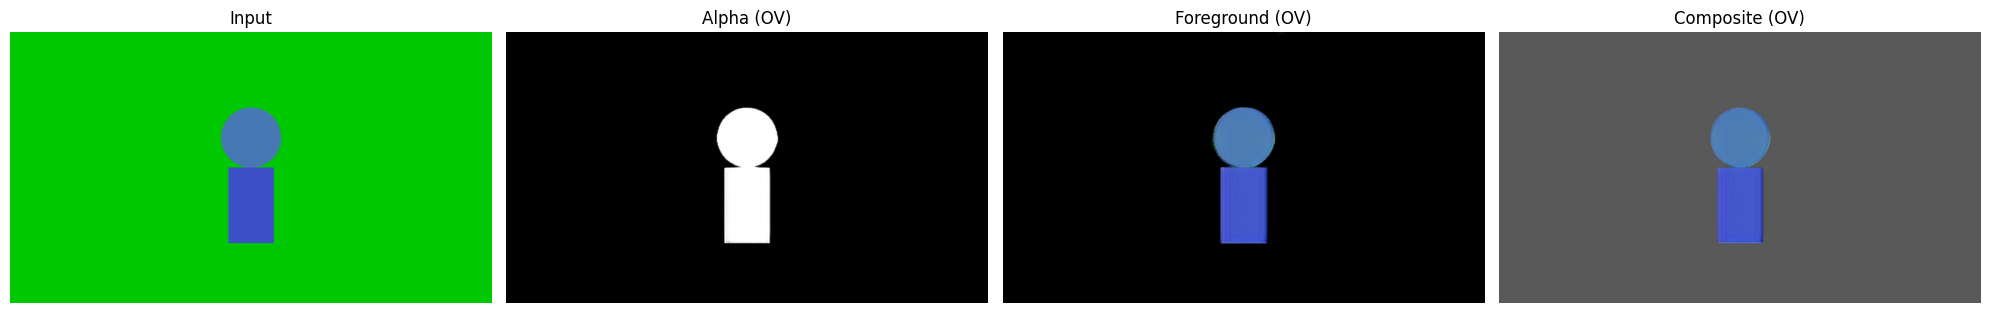

In [8]:
# Generate synthetic input
image_bgr = make_synthetic_greenscreen()
inp, orig_h, orig_w = preprocess(image_bgr, IMG_SIZE)

# --- OpenVINO inference ---
t0 = time.perf_counter()
ov_results = compiled(inp)
ov_ms = (time.perf_counter() - t0) * 1000
print(f"OpenVINO inference: {ov_ms:.1f} ms")

alpha_ov, fg_ov, comp_ov = postprocess(ov_results[0], ov_results[1], orig_h, orig_w)

# --- Display ---
input_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax in axes:
    ax.axis("off")

axes[0].imshow(input_rgb)
axes[0].set_title("Input")

axes[1].imshow(alpha_ov, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Alpha (OV)")

axes[2].imshow(fg_ov)
axes[2].set_title("Foreground (OV)")

axes[3].imshow(comp_ov)
axes[3].set_title("Composite (OV)")

plt.tight_layout()
plt.show()

## 9. PyTorch vs OpenVINO Comparison

Run the same input through both backends and compare outputs numerically.

Mean |alpha_ov - alpha_pt| = 0.000001
Mean |fg_ov    - fg_pt|    = 0.000005


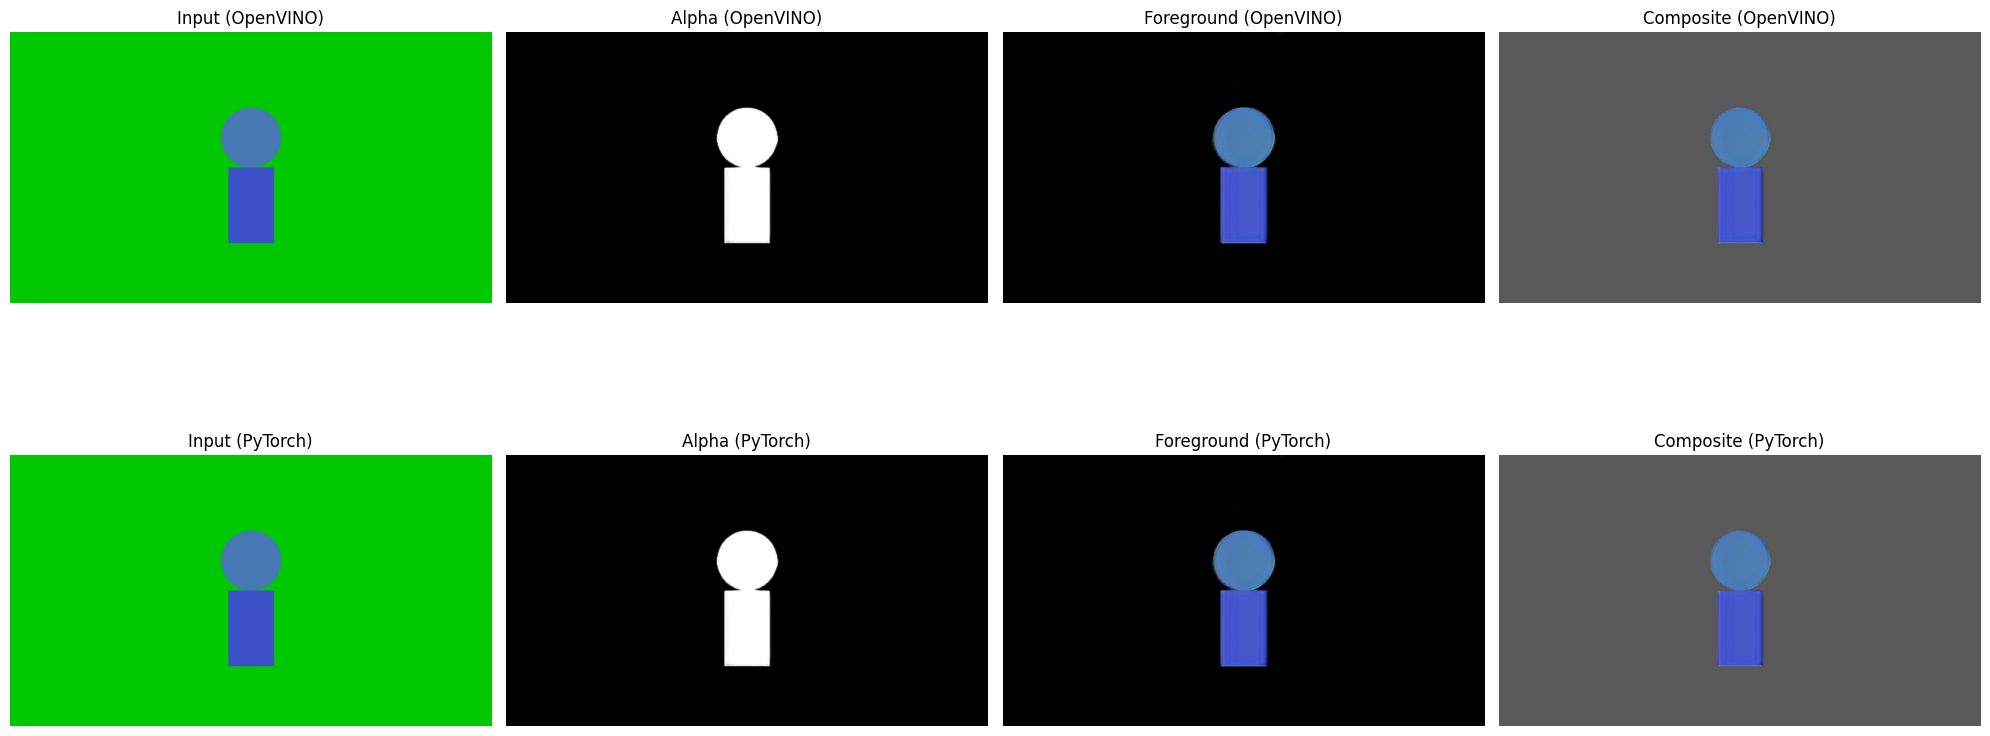

In [9]:
# --- PyTorch inference ---
inp_t = torch.from_numpy(inp)
with torch.inference_mode():
    t0 = time.perf_counter()
    pt_out = torch_model(inp_t)
    pt_ms = (time.perf_counter() - t0) * 1000

pt_alpha_raw = pt_out["alpha"].numpy()
pt_fg_raw = pt_out["fg"].numpy()
alpha_pt, fg_pt, comp_pt = postprocess(pt_alpha_raw, pt_fg_raw, orig_h, orig_w)

# --- Numerical diff ---
alpha_diff = np.abs(ov_results[0][0, 0] - pt_alpha_raw[0, 0]).mean()
fg_diff = np.abs(ov_results[1] - pt_fg_raw).mean()
print(f"Mean |alpha_ov - alpha_pt| = {alpha_diff:.6f}")
print(f"Mean |fg_ov    - fg_pt|    = {fg_diff:.6f}")

# --- Visual comparison ---
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for row in axes:
    for ax in row:
        ax.axis("off")

titles = ["Input", "Alpha", "Foreground", "Composite"]
ov_imgs = [input_rgb, alpha_ov, fg_ov, comp_ov]
pt_imgs = [input_rgb, alpha_pt, fg_pt, comp_pt]

for i, (title, ov_img, pt_img) in enumerate(zip(titles, ov_imgs, pt_imgs)):
    kw = {"cmap": "gray", "vmin": 0, "vmax": 1} if i == 1 else {}
    axes[0][i].imshow(ov_img, **kw)
    axes[0][i].set_title(f"{title} (OpenVINO)")
    axes[1][i].imshow(pt_img, **kw)
    axes[1][i].set_title(f"{title} (PyTorch)")

plt.tight_layout()
plt.show()

## 10. Video Inference

Generate a synthetic green-screen video (animated figure moving across the frame), run per-frame inference, and write output videos.

In [10]:
N_FRAMES = 30
VID_FPS = 30.0
H, W = 720, 1280

# Generate synthetic video frames
print(f"Generating {N_FRAMES}-frame synthetic green-screen video ({W}×{H}) …")
frames = []
for i in range(N_FRAMES):
    img = np.zeros((H, W, 3), dtype=np.uint8)
    img[:, :] = (0, 200, 0)  # BGR green
    t = i / max(N_FRAMES - 1, 1)
    cx = int(W * 0.15 + W * 0.70 * t)
    cy = H // 2
    cv2.circle(img, (cx, cy - 80), 80, (180, 120, 70), -1)
    cv2.rectangle(img, (cx - 60, cy), (cx + 60, cy + 200), (200, 80, 60), -1)
    frames.append(img)

# Write input + output videos
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
fourcc = cv2.VideoWriter_fourcc(*"mp4v")

input_writer = cv2.VideoWriter(str(OUTPUT_DIR / "input.mp4"), fourcc, VID_FPS, (W, H))
alpha_writer = cv2.VideoWriter(str(OUTPUT_DIR / "alpha.mp4"), fourcc, VID_FPS, (W, H), isColor=False)
fg_writer = cv2.VideoWriter(str(OUTPUT_DIR / "foreground.mp4"), fourcc, VID_FPS, (W, H))
comp_writer = cv2.VideoWriter(str(OUTPUT_DIR / "composite.mp4"), fourcc, VID_FPS, (W, H))

total_ms = 0.0
for idx, frame_bgr in enumerate(frames):
    input_writer.write(frame_bgr)
    inp_v, h, w = preprocess(frame_bgr, IMG_SIZE)

    t0 = time.perf_counter()
    res = compiled(inp_v)
    dt = (time.perf_counter() - t0) * 1000
    total_ms += dt

    a, f, c = postprocess(res[0], res[1], h, w)
    alpha_writer.write((a * 255).astype(np.uint8))
    fg_writer.write((cv2.cvtColor(f, cv2.COLOR_RGB2BGR) * 255).astype(np.uint8))
    comp_writer.write((cv2.cvtColor(c, cv2.COLOR_RGB2BGR) * 255).astype(np.uint8))

    if idx % 10 == 0 or idx == N_FRAMES - 1:
        print(f"  frame {idx + 1}/{N_FRAMES}  ({dt:.1f} ms)")

for wr in (input_writer, alpha_writer, fg_writer, comp_writer):
    wr.release()

avg = total_ms / N_FRAMES
print(f"\n✓ Video done: {N_FRAMES} frames, avg {avg:.1f} ms/frame ({1000 / avg:.1f} fps)")
print(f"  Saved to {OUTPUT_DIR.resolve()}/")
for f in sorted(OUTPUT_DIR.glob("*.mp4")):
    print(f"    {f.name:25s}  {f.stat().st_size / 1e3:.0f} KB")

Generating 30-frame synthetic green-screen video (1280×720) …
  frame 1/30  (362.9 ms)
  frame 1/30  (362.9 ms)
  frame 11/30  (363.4 ms)
  frame 11/30  (363.4 ms)
  frame 21/30  (360.0 ms)
  frame 21/30  (360.0 ms)
  frame 30/30  (360.3 ms)

✓ Video done: 30 frames, avg 360.0 ms/frame (2.8 fps)
  Saved to /home/dlyakhov/Projects/CorridorKeyOpenVINO/output/
    alpha.mp4                  115 KB
    composite.mp4              109 KB
    foreground.mp4             123 KB
    input.mp4                  95 KB
  frame 30/30  (360.3 ms)

✓ Video done: 30 frames, avg 360.0 ms/frame (2.8 fps)
  Saved to /home/dlyakhov/Projects/CorridorKeyOpenVINO/output/
    alpha.mp4                  115 KB
    composite.mp4              109 KB
    foreground.mp4             123 KB
    input.mp4                  95 KB


### Display a few video frames

Show the first, middle, and last frame side-by-side.

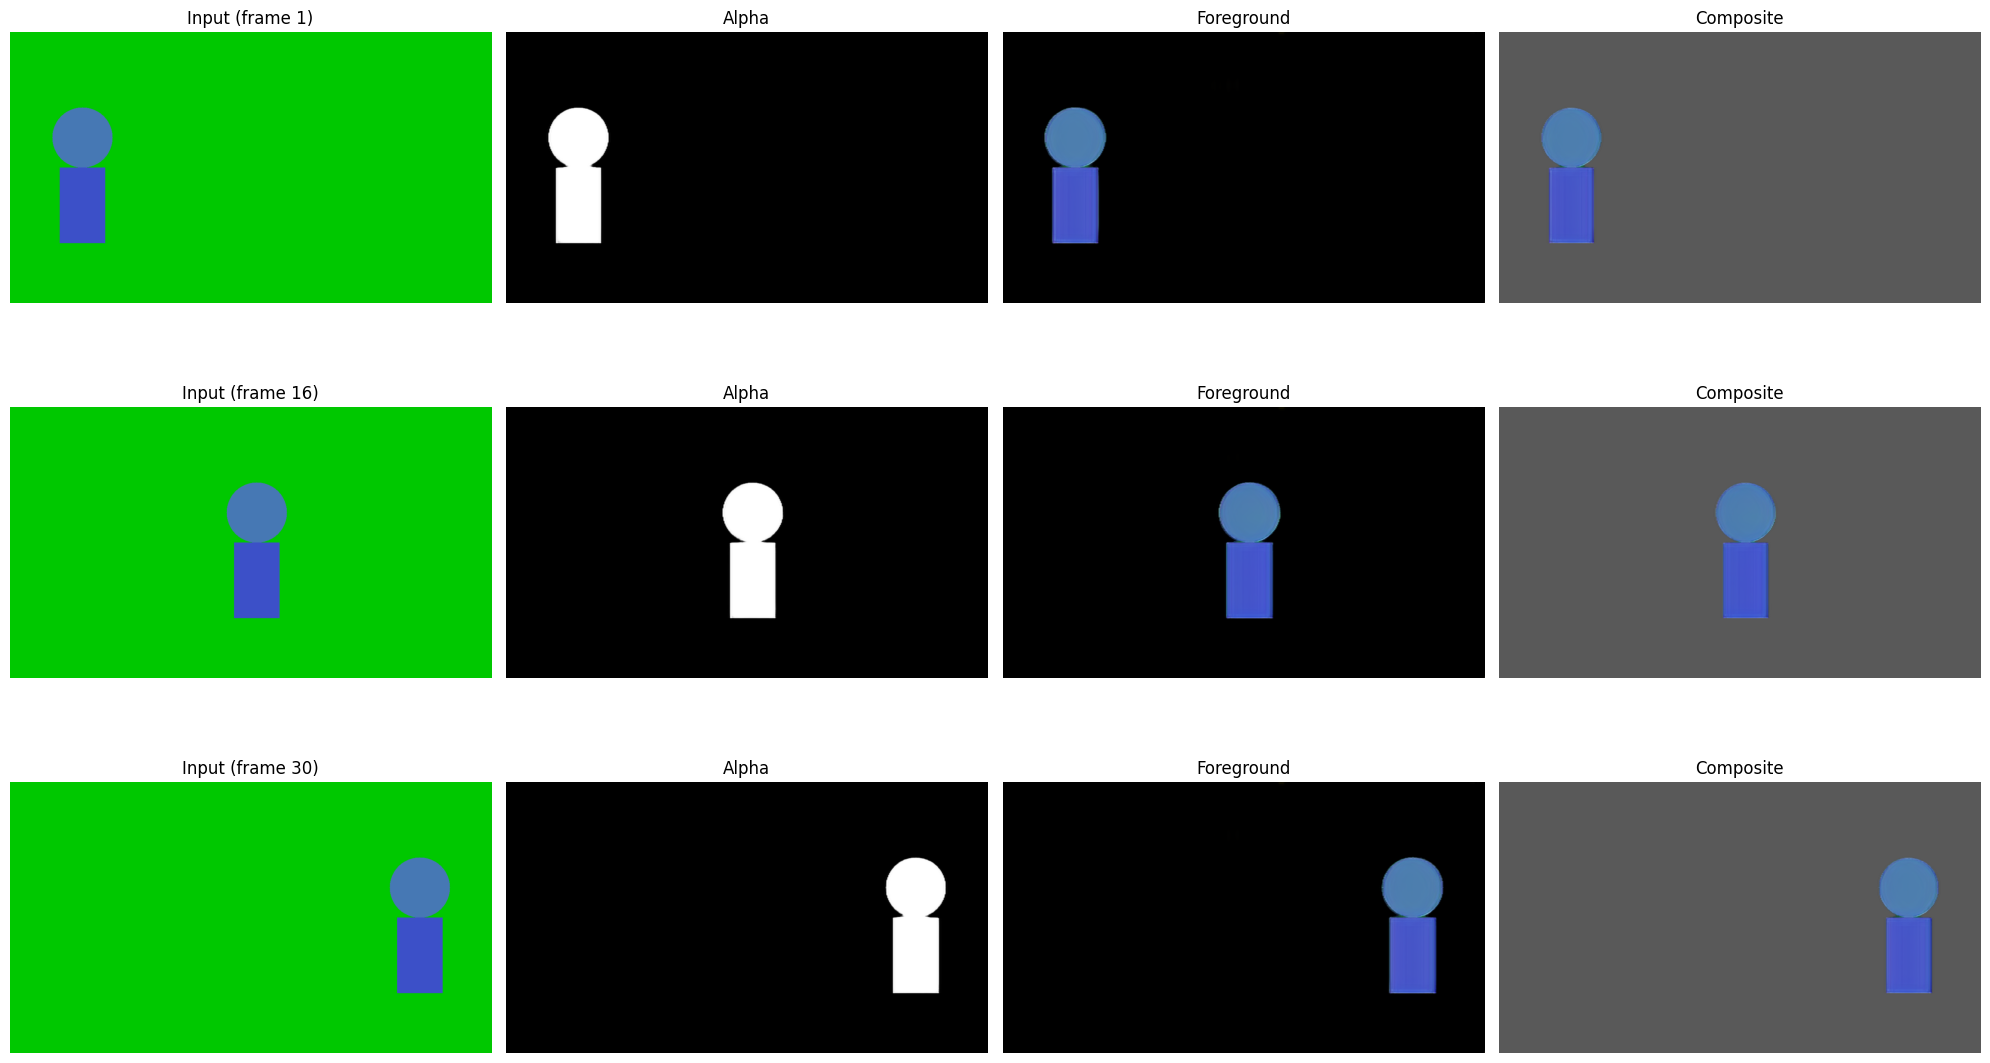

In [11]:
# Pick 3 sample frames from the synthetic video
sample_indices = [0, N_FRAMES // 2, N_FRAMES - 1]

fig, axes = plt.subplots(len(sample_indices), 4, figsize=(20, 4 * len(sample_indices)))

for row, idx in enumerate(sample_indices):
    frame_bgr = frames[idx]
    inp_s, h_s, w_s = preprocess(frame_bgr, IMG_SIZE)
    res_s = compiled(inp_s)
    a_s, f_s, c_s = postprocess(res_s[0], res_s[1], h_s, w_s)

    in_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0

    axes[row][0].imshow(in_rgb)
    axes[row][0].set_title(f"Input (frame {idx + 1})")
    axes[row][1].imshow(a_s, cmap="gray", vmin=0, vmax=1)
    axes[row][1].set_title("Alpha")
    axes[row][2].imshow(f_s)
    axes[row][2].set_title("Foreground")
    axes[row][3].imshow(c_s)
    axes[row][3].set_title("Composite")

    for ax in axes[row]:
        ax.axis("off")

plt.tight_layout()
plt.show()

## 11. Benchmark: OpenVINO vs PyTorch

Run multiple iterations on the same input and compare average latency.

Backend,Avg latency (ms),Speedup
PyTorch (CPU),697.1,1.00×
OpenVINO (CPU),349.5,1.99×


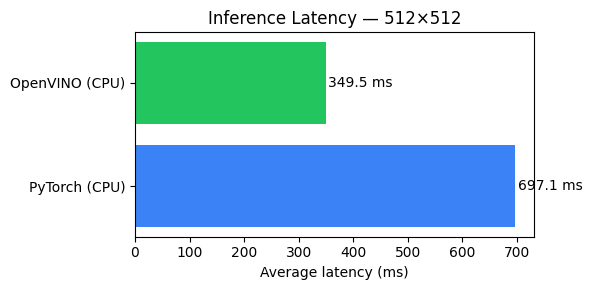

In [12]:
import pandas as pd

N_WARMUP = 3
N_BENCH = 10

# Use the same preprocessed input from the image section
bench_inp = inp  # [1, 4, IMG_SIZE, IMG_SIZE]
bench_inp_t = torch.from_numpy(bench_inp)

# --- Warmup ---
for _ in range(N_WARMUP):
    compiled(bench_inp)
    with torch.inference_mode():
        torch_model(bench_inp_t)

# --- OpenVINO benchmark ---
ov_times = []
for _ in range(N_BENCH):
    t0 = time.perf_counter()
    compiled(bench_inp)
    ov_times.append((time.perf_counter() - t0) * 1000)

# --- PyTorch benchmark ---
pt_times = []
for _ in range(N_BENCH):
    with torch.inference_mode():
        t0 = time.perf_counter()
        torch_model(bench_inp_t)
        pt_times.append((time.perf_counter() - t0) * 1000)

ov_avg = np.mean(ov_times)
pt_avg = np.mean(pt_times)
speedup = pt_avg / ov_avg

# --- Results table (rendered as HTML in notebook) ---
df = pd.DataFrame(
    {
        "Backend": ["PyTorch (CPU)", f"OpenVINO ({OV_DEVICE})"],
        "Avg latency (ms)": [f"{pt_avg:.1f}", f"{ov_avg:.1f}"],
        "Speedup": ["1.00×", f"{speedup:.2f}×"],
    }
)
display(df.style.hide(axis="index").set_caption(f"Benchmark — {N_BENCH} iterations, {IMG_SIZE}×{IMG_SIZE}"))

# --- Bar chart ---
fig, ax = plt.subplots(figsize=(6, 3))
bars = ax.barh(["PyTorch (CPU)", f"OpenVINO ({OV_DEVICE})"], [pt_avg, ov_avg], color=["#3b82f6", "#22c55e"])
ax.set_xlabel("Average latency (ms)")
ax.set_title(f"Inference Latency — {IMG_SIZE}×{IMG_SIZE}")
for bar, val in zip(bars, [pt_avg, ov_avg]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2, f"{val:.1f} ms", va="center")
plt.tight_layout()
plt.show()